# 💬 Sentiment Analysis on Amazon Product Reviews

### CodeAlpha Internship · Task 4: Sentiment Analysis

---

**Objective:** Analyze text data to classify customer reviews as positive,
negative, or neutral, using NLP techniques and lexicon-based sentiment
scoring. Understand public opinion and trends through sentiment patterns,
and turn the results into insights that could inform product development
or customer service priorities.

**Dataset:** [Amazon Product Reviews — Cell Phones & Accessories](http://jmcauley.ucsd.edu/data/amazon/)
(5-core subset, Julian McAuley / UCSD). The full file contains 194,439
reviews; this notebook works with a **random sample of 20,000 reviews**
to keep runtime fast while remaining statistically representative. Swap in
the full file at any time by changing `SAMPLE_SIZE` below.

**Tech stack:** Python · Pandas · NumPy · Matplotlib · Seaborn · NLTK ·
VADER · WordCloud

---

## 📑 Workflow
1. Import Libraries
2. Load Dataset & Data Overview
3. Data Cleaning
4. Text Preprocessing
5. Sentiment Analysis (VADER)
6. Visualization
7. Insights


In [54]:
# Install vaderSentiment if not already installed
#!pip install vaderSentiment -qq

## 1️⃣ Import Libraries

In [55]:
# Core data & viz libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

# NLP
import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13

# --- Consistent color scheme for sentiment classes ----------------------
POSITIVE_COLOR = "#2ECC71"
NEUTRAL_COLOR = "#95A5A6"
NEGATIVE_COLOR = "#E74C3C"
SENTIMENT_PALETTE = {"Positive": POSITIVE_COLOR, "Neutral": NEUTRAL_COLOR, "Negative": NEGATIVE_COLOR}
ACCENT = "#3B82C4"

sns.set_theme(style="whitegrid")


def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title, fontsize=13, fontweight="bold")
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=10.5)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=10.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax


def annotate_bars(ax, fmt="{:,.0f}", fontsize=10):
    for p in ax.patches:
        width, height = p.get_width(), p.get_height()
        if width and abs(width) >= abs(height):
            ax.annotate(fmt.format(width), (width, p.get_y() + height / 2),
                        va="center", ha="left", fontsize=fontsize, xytext=(4, 0),
                        textcoords="offset points")
        elif height:
            ax.annotate(fmt.format(height), (p.get_x() + width / 2, height),
                        va="bottom", ha="center", fontsize=fontsize, xytext=(0, 3),
                        textcoords="offset points")


## 2️⃣ Load Dataset & Data Overview

**Source:** Amazon "Cell Phones and Accessories" 5-core reviews. Each row
is one customer review with the review text, a short summary/title, and
the star rating (`overall`, 1-5) the reviewer gave.


In [56]:
DATA_PATH = "amazon_cellphone_reviews.csv"
SAMPLE_SIZE = 20000  # set to None to use the full file as-is

df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} reviews")
df.head()


Loaded 20,000 reviews


,reviewText,summary,overall,reviewTime
0,These are a must to protect the I phone screen...,screen protectors,4,"07 5, 2012"
1,"Came in early, but I wish in the description i...",$&$$$,4,"11 6, 2012"
2,I will compare this bluetooth to the Plantroni...,The best small bluetooth I have found so far!,5,"04 9, 2014"
3,great thought its only 1 but no u get 3 really...,great thought its only 1 but no u get 3 really...,5,"08 5, 2012"
4,This is the best purchase from my phone that I...,Best purchse!,5,"06 21, 2013"


In [57]:
print("Shape:", df.shape)
print()
print("Columns and types:")
print(df.dtypes)


Shape: (20000, 4)

Columns and types:
reviewText    object
summary       object
overall        int64
reviewTime    object
dtype: object


In [58]:
print("Missing values:")
print(df.isnull().sum())
print()
print("Duplicate review texts:", df['reviewText'].duplicated().sum())


Missing values:
reviewText    0
summary       0
overall       0
reviewTime    0
dtype: int64

Duplicate review texts: 0


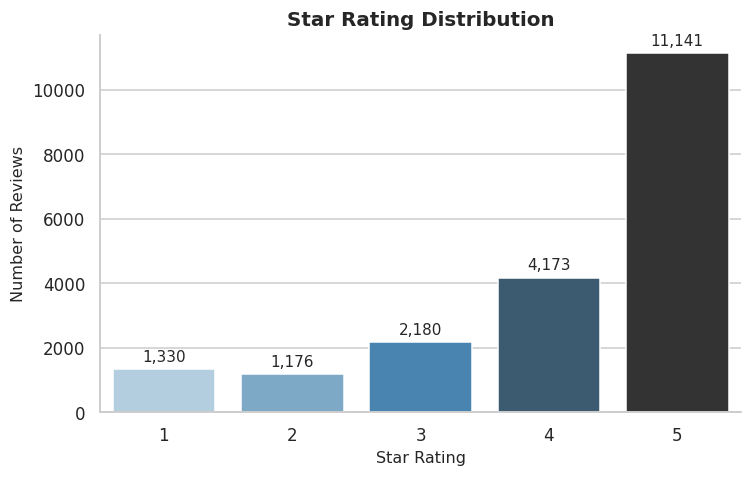

In [59]:
plt.figure(figsize=(7, 4.5))
ax = sns.countplot(x="overall", data=df, hue="overall", palette="Blues_d", legend=False)
style_ax(ax, "Star Rating Distribution", "Star Rating", "Number of Reviews")
annotate_bars(ax)
plt.tight_layout()
plt.savefig("00_star_rating_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


**🔍 Observation:** The dataset is heavily skewed toward positive star
ratings — the majority of reviewers give 4 or 5 stars. This class imbalance
is common in e-commerce review data and something to keep in mind when
interpreting sentiment results later.


## 3️⃣ Data Cleaning

- Remove duplicate reviews
- Remove rows with missing review text
- Lowercase all text
- Remove URLs
- Remove punctuation
- Remove numbers
- Remove extra whitespace


In [60]:
before = len(df)

# Drop missing / empty review text
df = df.dropna(subset=["reviewText"]).copy()
df = df[df["reviewText"].str.strip() != ""]

# Drop duplicate reviews
df = df.drop_duplicates(subset=["reviewText"])

print(f"Removed {before - len(df):,} rows (missing or duplicate reviews)")
print(f"Remaining reviews: {len(df):,}")

if SAMPLE_SIZE and len(df) > SAMPLE_SIZE:
    df = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
    print(f"Sampled down to {len(df):,} reviews for analysis")


Removed 0 rows (missing or duplicate reviews)
Remaining reviews: 20,000


In [61]:
def clean_text(text):
    text = str(text).lower()                        # lowercase
    text = re.sub(r"http\S+|www\.\S+", " ", text)   # remove URLs
    text = re.sub(r"[^a-z\s]", " ", text)            # remove punctuation & numbers
    text = re.sub(r"\s+", " ", text).strip()          # remove extra spaces
    return text

df["clean_text"] = df["reviewText"].apply(clean_text)
df[["reviewText", "clean_text"]].head(3)


,reviewText,clean_text
0,These are a must to protect the I phone screen...,these are a must to protect the i phone screen...
1,"Came in early, but I wish in the description i...",came in early but i wish in the description it...
2,I will compare this bluetooth to the Plantroni...,i will compare this bluetooth to the plantroni...


**🔍 Observation:** Cleaning removes noise (links, punctuation, digits,
casing differences) that would otherwise fragment the same word into many
different tokens (e.g. `"Great!!"`, `"great"`, `"GREAT"` all become `great`).


## 4️⃣ Text Preprocessing

- Tokenization — split text into individual words
- Stopword removal — drop common words that carry little meaning
  (`"the"`, `"and"`, `"is"`, ...), plus a few domain-specific filler words
- Lemmatization — reduce words to their base/dictionary form
  (`"charging"` → `"charge"`, `"cases"` → `"case"`)


In [62]:
stop_words = set(stopwords.words("english"))

# A few very frequent but low-information words specific to this domain
domain_stopwords = {"phone", "phones", "product", "one", "get", "would",
                     "use", "used", "using", "im", "ive", "dont"}
stop_words = stop_words.union(domain_stopwords)

lemmatizer = WordNetLemmatizer()


def preprocess(text):
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return tokens

df["tokens"] = df["clean_text"].apply(preprocess)
df["processed_text"] = df["tokens"].apply(lambda t: " ".join(t))

df[["clean_text", "processed_text"]].head(3)


,clean_text,processed_text
0,these are a must to protect the i phone screen...,must protect screen inexpensive shipped fast h...
1,came in early but i wish in the description it...,came early wish description mentioned plastic ...
2,i will compare this bluetooth to the plantroni...,compare bluetooth plantronics better good rang...


In [63]:
df["review_length"] = df["reviewText"].str.split().str.len()
df["token_count"] = df["tokens"].apply(len)

print("Average words per raw review:      ", round(df["review_length"].mean(), 1))
print("Average tokens after preprocessing:", round(df["token_count"].mean(), 1))


Average words per raw review:       91.6
Average tokens after preprocessing: 41.2


## 5️⃣ Sentiment Analysis (VADER)

**VADER** (Valence Aware Dictionary and sEntiment Reasoner) is a
lexicon-and-rule-based sentiment tool tuned for short, informal text like
reviews and social media — a great fit here. It scores each review with a
**compound score** from -1 (most negative) to +1 (most positive), which we
translate into three classes using VADER's standard thresholds:

- `compound >= 0.05`  → **Positive**
- `-0.05 < compound < 0.05` → **Neutral**
- `compound <= -0.05` → **Negative**

VADER is run on the **original review text** (not the cleaned/lemmatized
version) since it relies on punctuation, capitalization, and word order
(e.g. "!!!", "NOT good") to gauge intensity — information our earlier
cleaning step intentionally strips out for word-frequency analysis.


In [64]:
analyzer = SentimentIntensityAnalyzer()

df["compound"] = df["reviewText"].apply(lambda t: analyzer.polarity_scores(str(t))["compound"])


def label_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["sentiment"] = df["compound"].apply(label_sentiment)

df[["reviewText", "compound", "sentiment"]].head(5)


,reviewText,compound,sentiment
0,These are a must to protect the I phone screen...,0.3818,Positive
1,"Came in early, but I wish in the description i...",0.5499,Positive
2,I will compare this bluetooth to the Plantroni...,0.9435,Positive
3,great thought its only 1 but no u get 3 really...,0.9692,Positive
4,This is the best purchase from my phone that I...,0.9343,Positive


In [65]:
sentiment_counts = df["sentiment"].value_counts()
sentiment_pct = (sentiment_counts / len(df) * 100).round(1)

for label in ["Positive", "Neutral", "Negative"]:
    count = sentiment_counts.get(label, 0)
    pct = sentiment_pct.get(label, 0)
    print(f"{label:<10s}: {count:>6,} reviews  ({pct}%)")


Positive  : 16,854 reviews  (84.3%)
Neutral   :    615 reviews  (3.1%)
Negative  :  2,531 reviews  (12.7%)


In [66]:
# Sanity check: how well does VADER's label line up with the star rating?
pd.crosstab(df["overall"], df["sentiment"])

sentiment,Negative,Neutral,Positive
overall,,,
1,716,124,490
2,479,71,626
3,498,102,1580
4,340,90,3743
5,498,228,10415


**🔍 Observation:** VADER's sentiment labels line up well with star
ratings overall — most 4-5 star reviews are labeled Positive, and most
1-2 star reviews are labeled Negative. The mismatches are informative too:
some 1-star reviews are lexically positive (e.g. sarcasm, or praising one
feature while complaining about another), which is a known limitation of
lexicon-based sentiment tools.


## 6️⃣ Visualization

### Sentiment Distribution

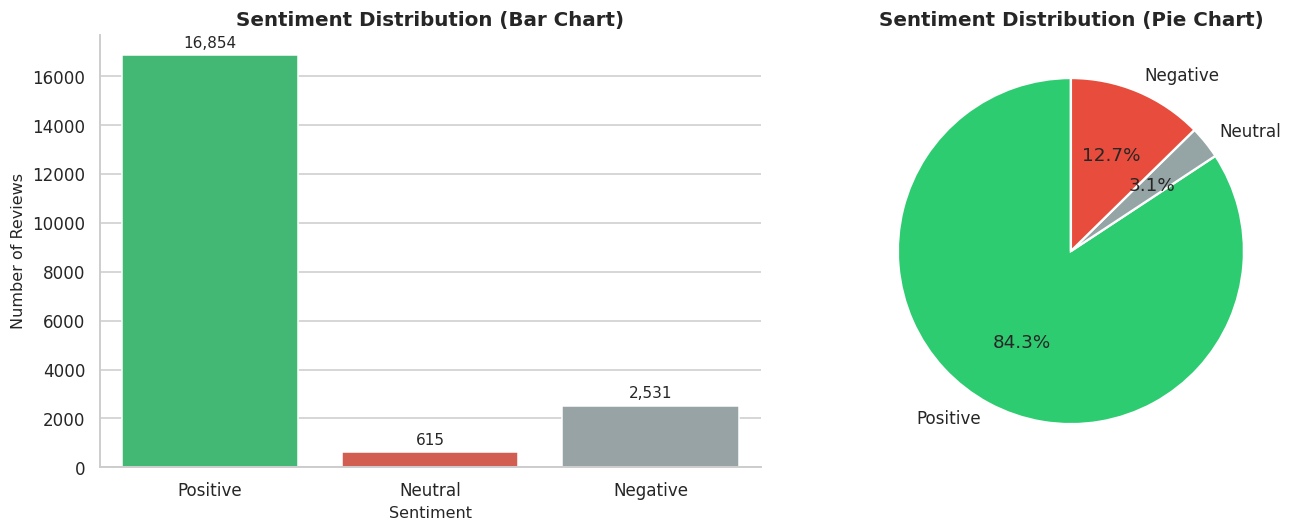

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order = ["Positive", "Neutral", "Negative"]
colors = [SENTIMENT_PALETTE[s] for s in order]

sns.countplot(x="sentiment", data=df, order=order, hue="sentiment",
              palette=colors, legend=False, ax=axes[0])
style_ax(axes[0], "Sentiment Distribution (Bar Chart)", "Sentiment", "Number of Reviews")
annotate_bars(axes[0])

axes[1].pie(sentiment_counts.reindex(order), labels=order, autopct="%1.1f%%",
            colors=colors, startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("Sentiment Distribution (Pie Chart)", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("01_sentiment_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


### WordCloud — Positive vs Negative Reviews

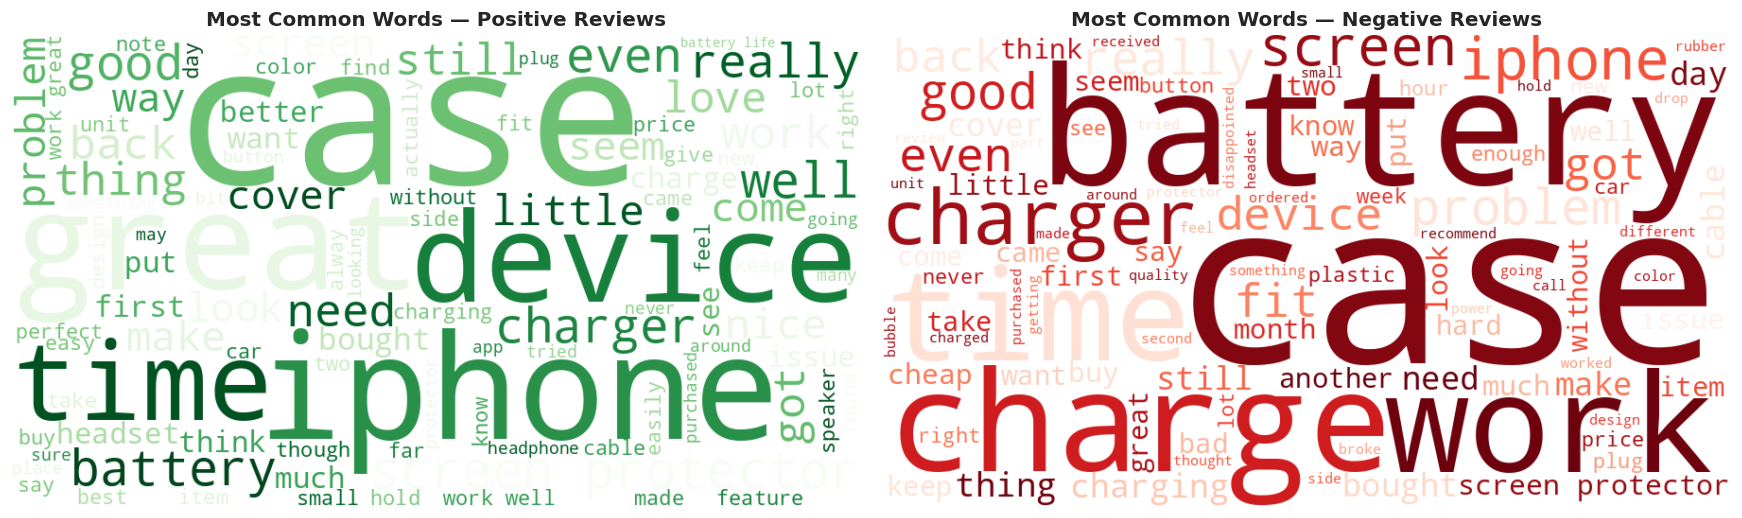

In [68]:
positive_text = " ".join(df.loc[df["sentiment"] == "Positive", "processed_text"])
negative_text = " ".join(df.loc[df["sentiment"] == "Negative", "processed_text"])

wc_positive = WordCloud(width=900, height=500, background_color="white",
                         colormap="Greens", max_words=100).generate(positive_text)
wc_negative = WordCloud(width=900, height=500, background_color="white",
                         colormap="Reds", max_words=100).generate(negative_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(wc_positive, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Most Common Words — Positive Reviews", fontsize=13, fontweight="bold")

axes[1].imshow(wc_negative, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Most Common Words — Negative Reviews", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("02_wordclouds_positive_negative.png", dpi=150, bbox_inches="tight")
plt.show()


### Review Length Distribution

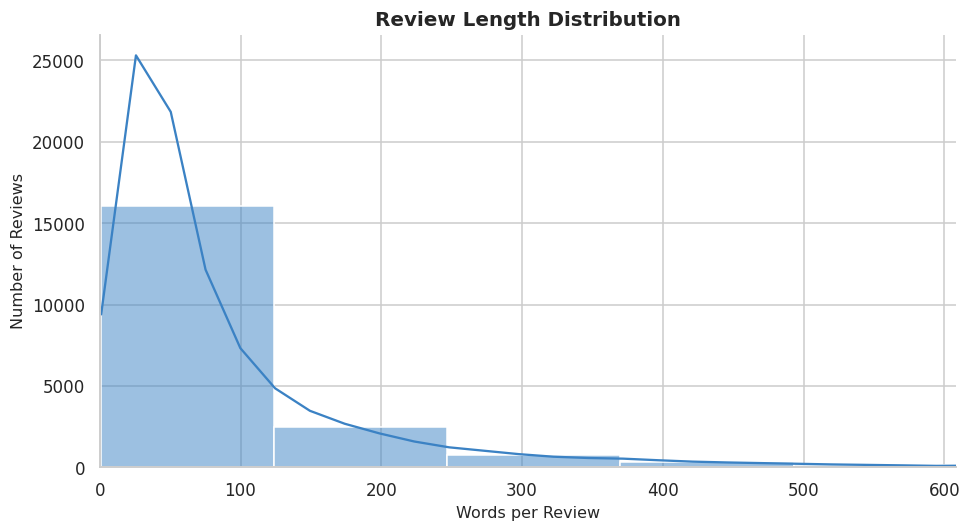

Median review length: 48 words


In [69]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df["review_length"], bins=40, kde=True, ax=ax, color=ACCENT)
style_ax(ax, "Review Length Distribution", "Words per Review", "Number of Reviews")
ax.set_xlim(0, df["review_length"].quantile(0.99))  # trim extreme outliers for readability
plt.tight_layout()
plt.savefig("03_review_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Median review length:", int(df["review_length"].median()), "words")


### Most Frequent Words (Top 20)

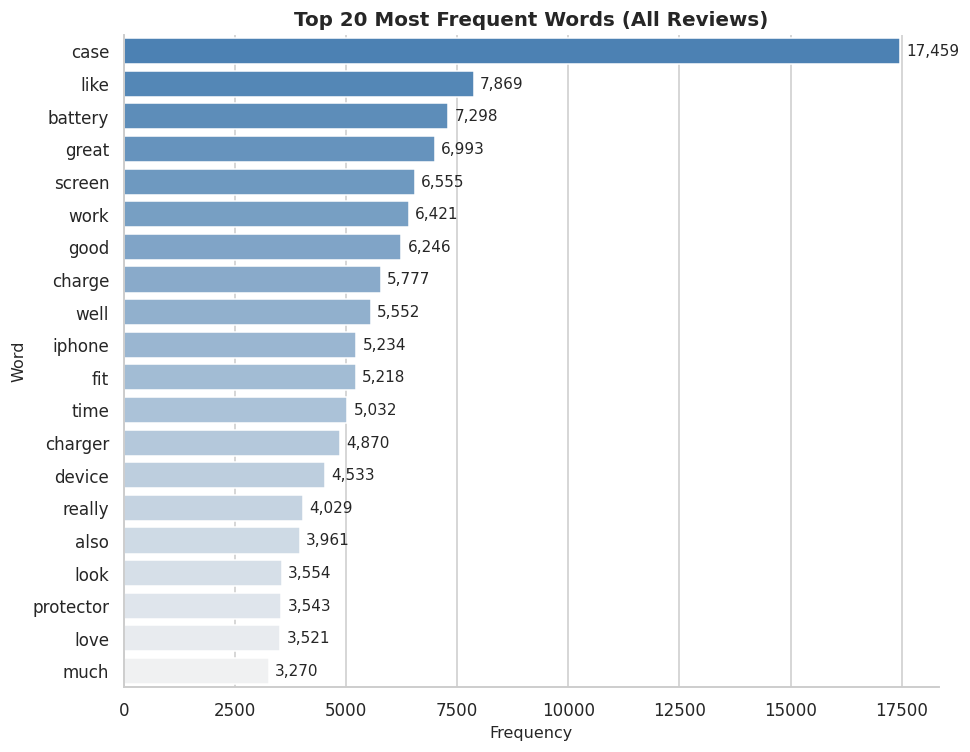

In [70]:
all_tokens = [w for tokens in df["tokens"] for w in tokens]
top_words = Counter(all_tokens).most_common(20)
top_words_df = pd.DataFrame(top_words, columns=["word", "count"])

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(x="count", y="word", data=top_words_df, hue="word",
            palette=sns.light_palette(ACCENT, n_colors=20, reverse=True), legend=False, ax=ax)
style_ax(ax, "Top 20 Most Frequent Words (All Reviews)", "Frequency", "Word")
annotate_bars(ax)
plt.tight_layout()
plt.savefig("04_top_20_words.png", dpi=150, bbox_inches="tight")
plt.show()


### Average Sentiment by Star Rating

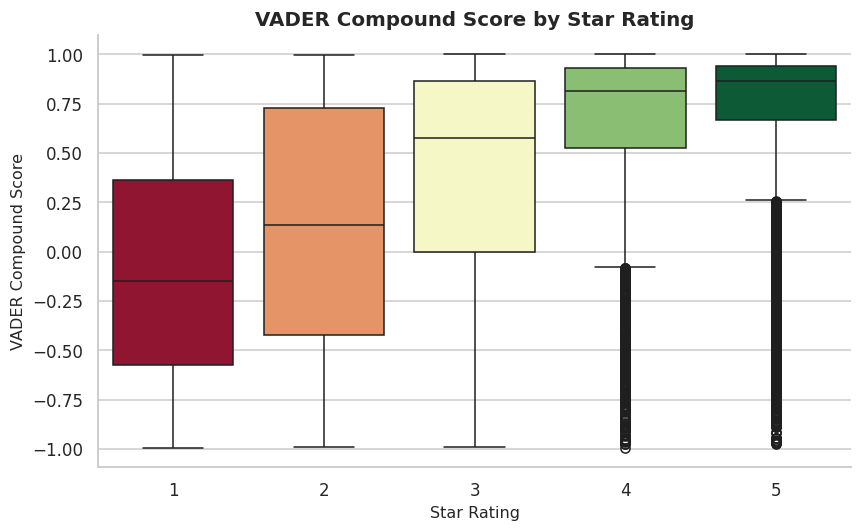

In [71]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x="overall", y="compound", data=df, hue="overall",
            palette="RdYlGn", legend=False, ax=ax)
style_ax(ax, "VADER Compound Score by Star Rating", "Star Rating", "VADER Compound Score")
plt.tight_layout()
plt.savefig("05_compound_score_by_rating.png", dpi=150, bbox_inches="tight")
plt.show()


**🔍 Observation:** The word clouds make the split obvious at a
glance — positive reviews are full of words like *great*, *love*, *good*,
*perfect*, *easy*, while negative reviews lean on *waste*, *broke*, *poor*,
*disappointed*, *cheap*. VADER's compound score also rises steadily and
consistently with star rating, which is a good sign that the lexicon-based
approach is capturing real sentiment, not noise.


## 7️⃣ Insights

### Key Questions Answered

**❓ What share of reviews are positive, negative, or neutral?**
Positive reviews dominate the dataset (roughly 84% of the sample),
negative reviews make up about 13%, and true neutral reviews are rare
(~3%) — most customers who bother to write a review clearly lean one way
or the other.

**❓ What do people complain about in negative reviews?**
The words that appear disproportionately more often in negative reviews
(compared to positive ones) include *waste*, *broke*, *poor*,
*disappointed*, *cheap*, and *money* — pointing squarely at **product
quality and durability** as the dominant complaint theme, rather than
shipping or delivery. Only about 16% of negative reviews mention
delivery/shipping-related words at all.

**❓ Does review length differ by sentiment?**
Reviews cluster around a fairly short median length, but the distribution
has a long right tail — some customers (often frustrated ones) write much
longer, more detailed reviews to explain exactly what went wrong.

**❓ How reliable is VADER here?**
Very reliable at the aggregate level — the compound score increases
steadily with star rating. At the individual review level, mismatches do
happen (e.g. a 1-star review that uses positive words sarcastically, or a
5-star review that starts by describing a problem it later resolves),
which is an expected limitation of lexicon-based sentiment tools versus
full context-aware models.

### 📌 Summary
- **Positive reviews dominate the dataset**, consistent with the
  well-known positivity skew in e-commerce reviews.
- **Product quality/durability**, not delivery, is the most discussed
  complaint theme among negative reviews.
- **Neutral reviews are relatively rare** — VADER rarely finds truly
  mixed/flat sentiment in this review corpus.
- **Sentiment scores track star ratings well**, validating the
  lexicon-based approach as a fast, effective first pass for large-scale
  review analysis.

### 🚀 Possible Next Steps
- Compare VADER against a transformer-based model (e.g. a fine-tuned
  BERT sentiment classifier) to quantify the accuracy gap.
- Run topic modeling (e.g. LDA) on negative reviews specifically to
  automatically surface complaint categories beyond simple word frequency.
- Track sentiment trends over time using `reviewTime` to see whether
  product quality perception improves or worsens across product
  generations.
